## Variational problems that are optimization problems: the hanging rope

Lecture 3 ended with the question *when* a structure fails: the equivalent stresses of Rankine, Tresca and
von Mises decide it. This lecture asks *how the shape of a structure should be chosen* so that it fails as late as
possible, or deforms as little as possible, with a given amount of material: **shape optimization**. There are two
ways to arrive at a good shape. Nature offers one of them for free, as the minimum of a potential energy
(this section); the other is an algorithm that moves the boundary of the body step by step (the rest of the
lecture). Both are variational problems in the sense of lecture 2.

### The catenary

A rope of length $\ell$ hangs between two points, $y(0) = y(1) = 0$, in the gravitational field. The rope is
flexible, so its only stiffness is that it keeps its length: among all curves of length $\ell$ through the two points
it takes the one with the smallest potential energy. With the weight $\rho g$ per unit length and the arc element
$ds = \sqrt{1 + (y')^2} \, dx$,

$$\Pi[y] = \int_0^1 \rho g \, y \, \sqrt{1 + (y')^2} \, dx \;\to\; \min
  \qquad \text{subject to} \qquad \int_0^1 \sqrt{1 + (y')^2} \, dx = \ell .$$

The length constraint is handled as in lecture 2 (the slope of the beam): with a Lagrange multiplier $\lambda$,

$$\mathcal{L}[y, \lambda] = \int_0^1 \big(\rho g \, y - \lambda\big) \sqrt{1 + (y')^2} \, dx + \lambda \, \ell .$$

The Euler–Lagrange equation of $\mathcal{F}(y, y') = (\rho g \, y - \lambda)\sqrt{1 + (y')^2}$ reads
$\frac{d}{dx}\frac{\partial \mathcal{F}}{\partial y'} = \frac{\partial \mathcal{F}}{\partial y}$. Since $\mathcal{F}$
does not depend on $x$ explicitly, it has the first integral $\mathcal{F} - y' \, \partial\mathcal{F}/\partial y' = H$
(Beltrami's identity), which here becomes

$$\frac{\rho g \, y - \lambda}{\sqrt{1 + (y')^2}} = H = \text{const.} \qquad \Longrightarrow \qquad
  y(x) = \frac{\lambda}{\rho g} + a \cosh \frac{x - x_0}{a}, \qquad a = \frac{H}{\rho g} .$$

This is the **catenary** ("cosine hyperbolic curve"; Latin *catena*, chain). By symmetry $x_0 = \tfrac12$, and the
two remaining constants follow from $y(0) = 0$ and from the length,
$\ell = \int_0^1 \sqrt{1 + (y')^2} \, dx = 2a \sinh\frac{1}{2a}$, which fixes $a$. The multiplier and the first integral
have a meaning: $H$ is the horizontal component of the rope force, the same at every point of the rope, and
$\lambda = \rho g \, (y_{\min} - a)$ is the level at which the potential energy of the rope is measured (exercise 1).
The ends of the rope are Dirichlet conditions, the length is a constraint on the admissible set, and the shape
is the minimizer: the rope solves a shape optimization problem by hanging.

### No bending, only tension: the arch and the cupola

A rope has no bending stiffness, so it cannot carry a bending moment: the force in it is a pure tension along the
curve, and the curve adjusts itself until this is possible for the given load. This is what makes the catenary
remarkable for structural engineering. Turn it upside down and build it from a rigid material, and the tension
becomes a pure **compression** along the arch, again without bending. Robert Hooke stated this in 1675: as hangs the
flexible line, so, inverted, stands the rigid arch. Masonry, stone and concrete are brittle materials in the sense
of lecture 3: they fail by the Rankine criterion, at a tensile strength that is about a tenth of their compressive
strength. An arch or a dome whose line of thrust follows the inverted catenary carries its weight in compression
only, so that no tensile stress appears anywhere, and can therefore be built very large from a material that
"likes pressure but does not like to be pulled". The dome of Florence cathedral by Brunelleschi (1420–1436), the
largest masonry dome of its time, works on this principle; so does the Gateway Arch in St. Louis, a (weighted)
catenary turned upside down.

Antoni Gaudí turned the principle into a design method. For the crypt of the Colònia Güell and later for the
Sagrada Família he built *hanging models*: strings fixed to a board in the plan of the building, loaded with small
bags of lead shot in proportion to the weights of the vaults, hang down in the shape of the inverted structure.
Every string is a catenary, the whole net is a system of catenaries, and a photograph of the model turned upside
down shows the building, with all its arches and columns in pure compression. The photographs of his atelier
and of the restored model are easy to find online (Wikipedia: *Catenary*, *Catenary arch*, *Church of Colònia
Güell*). We first compute the catenary in FEniCS, then compare an arch built from it with a semicircular arch.

In [1]:
from fenics import *
from matplotlib import pyplot
import numpy as np
from scipy.optimize import brentq
%matplotlib inline

set_log_level(LogLevel.WARNING)   # silence the solver messages

### 1. The catenary as a constrained minimization

The rope on $(0, 1)$ with $\ell = 1.5$ and $\rho g = 1$. The unknowns are the function $y$ (quadratic Lagrange elements)
and the single number $\lambda$, for which FEniCS has the element `'R'` (a real number, one degree of freedom for the
whole mesh), combined in a mixed element as in lecture 2. `derivative` provides the stationarity conditions of
$\mathcal{L}$ with respect to both, and Newton's method solves them, started from a parabola of the right length.
The result is compared with the analytic catenary.

Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


a = 0.30824,  c = -0.81087,  length of the FE solution = 1.500000
max |y_h - y| = 5.8e-09
multiplier lambda_h = -0.81087,  rho g (y_min - a) = -0.81087


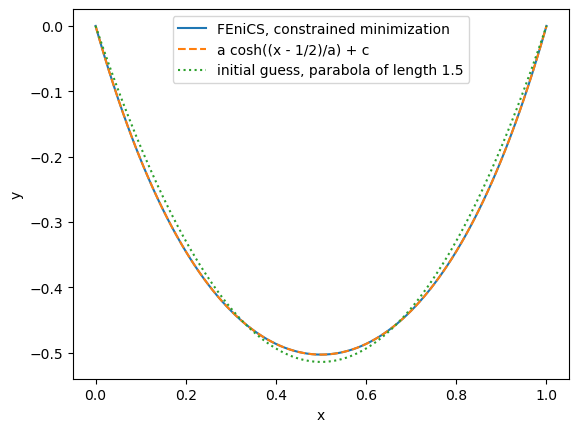

In [2]:
ell = 1.5

mesh_c = IntervalMesh(100, 0.0, 1.0)
P2 = FiniteElement('Lagrange', mesh_c.ufl_cell(), 2)
R  = FiniteElement('R', mesh_c.ufl_cell(), 0)          # one real number: the multiplier
V_c = FunctionSpace(mesh_c, MixedElement(P2, R))

y_lam = Function(V_c)
v     = TestFunction(V_c)
(y, lam) = split(y_lam)
ds_arc = sqrt(1 + y.dx(0)**2)
Lag = ( y*ds_arc - lam*(ds_arc - ell) )*dx            # rho g = 1
bc  = DirichletBC(V_c.sub(0), Constant(0.0), 'on_boundary')

# initial guess: the parabola -4 h x (1 - x) with length ell
xx = np.linspace(0.0, 1.0, 2001)
h0 = brentq(lambda h: np.trapz(np.sqrt(1 + (4*h*(1 - 2*xx))**2), xx) - ell, 0.01, 5.0)
y_lam.assign(interpolate(Expression(("-4*h*x[0]*(1 - x[0])", "lam0"), h=h0, lam0=-1.0, degree=2), V_c))

solve(derivative(Lag, y_lam, v) == 0, y_lam, bc)
y_h, lam_h = y_lam.split(deepcopy=True)

# analytic catenary: a from the length, c from y(0) = 0
a = brentq(lambda a: 2*a*np.sinh(1/(2*a)) - ell, 0.05, 5.0)
c = -a*np.cosh(1/(2*a))
xx  = np.linspace(0.0, 1.0, 201)
y_ex = a*np.cosh((xx - 0.5)/a) + c
print("a = %.5f,  c = %.5f,  length of the FE solution = %.6f" % (a, c, assemble(ds_arc*dx)))
print("max |y_h - y| = %.1e" % max(abs(y_h(x) - ye) for x, ye in zip(xx, y_ex)))
print("multiplier lambda_h = %.5f,  rho g (y_min - a) = %.5f" % (lam_h.vector().get_local()[0], c))

pyplot.figure(dpi=100)
pyplot.plot(xx, [y_h(x) for x in xx], label='FEniCS, constrained minimization')
pyplot.plot(xx, y_ex, '--', label='a cosh((x - 1/2)/a) + c')
pyplot.plot(xx, -4*h0*xx*(1 - xx), ':', label='initial guess, parabola of length %.1f' % ell)
pyplot.xlabel('x')
pyplot.ylabel('y')
pyplot.legend()
pyplot.savefig("catenary-0.png")

### 2. The inverted catenary as an arch

Two arches of the same span $2$, the same rise $1$ and the same thickness $0.15$, clamped at both feet, under their
own weight: one follows the inverted catenary $y = 1 - a(\cosh(x/a) - 1)$ with $a$ chosen for the rise, the other is a
semicircle. The meshes are rectangles in the parameters (arc length, thickness) mapped onto the arches, as for the
curved beam of the `linear-elasticity` notebook; the material and the stress helpers are those of lecture 3. A
constant-thickness arch under its own weight is loaded uniformly per unit *arc length*, exactly the load for which
the catenary is the funicular curve, so the catenary arch should be nearly free of tension, while the semicircle,
whose line of thrust leaves the centre line, must carry bending. The largest tensile stress (Rankine) decides where
a brittle material cracks first. (The small tensile spots at the feet of the catenary arch come from the clamping,
which forces the arch to bend there; hinged feet would remove them.)

In [3]:
tol = 1e-3
E, nu = 1000.0, 0.3
K = E/(3*(1 - 2*nu))
G = E/(2*(1 + nu))

def epsilon(u):
    return sym(grad(u))

def psi(eps):
    # strain energy density, volumetric + deviatoric part (3D deviator, plane strain)
    return 0.5*K*tr(eps)**2 + G*(inner(eps, eps) - tr(eps)**2/3)

def sigma(u):
    # stress = derivative of the strain energy with respect to the strain
    eps = variable(epsilon(u))
    return diff(psi(eps), eps)

def principal_stresses(u):
    # in-plane principal stresses (Mohr's circle) and the out-of-plane stress of plane strain
    s = sigma(u)
    c = 0.5*(s[0, 0] + s[1, 1])
    r = sqrt(0.25*(s[0, 0] - s[1, 1])**2 + s[0, 1]**2)
    s_zz = (K - 2*G/3)*tr(epsilon(u))          # lambda * tr(eps)
    return c + r, c - r, s_zz

def larger(a, b):
    return 0.5*(a + b + abs(a - b))

def smaller(a, b):
    return 0.5*(a + b - abs(a - b))

def sigma_1(u):
    s_a, s_b, s_zz = principal_stresses(u)      # s_a >= s_b always
    return larger(s_a, s_zz)

def sigma_3(u):
    s_a, s_b, s_zz = principal_stresses(u)
    return smaller(s_b, s_zz)

def rankine(u):
    return sigma_1(u)

def tresca(u):
    return sigma_1(u) - sigma_3(u)

def von_mises(u):
    s_a, s_b, s_zz = principal_stresses(u)
    return sqrt(0.5*((s_a - s_b)**2 + (s_b - s_zz)**2 + (s_zz - s_a)**2))

def left(x, on_boundary):
    return on_boundary and near(x[0], 0.0, tol)

def solve_elasticity(V, bcs, f=Constant((0.0, 0.0)), T=None, ds_T=None):
    # minimization of the total potential energy as in lecture 2; T is a traction on the boundary part ds_T
    u = Function(V)
    v = TestFunction(V)
    Pi = ( psi(epsilon(u)) - dot(f, u) )*dx
    if T is not None:
        Pi = Pi - dot(T, u)*ds_T
    solve(derivative(Pi, u, v) == 0, u, bcs)
    return u

def show_stresses(u, filename, layout=(3, 1), figsize=(8, 7), zoom=None):
    # the three equivalent stresses side by side (projected to P1 by plot)
    pyplot.figure(figsize=figsize, dpi=100)
    for i, (f, name) in enumerate(((von_mises, 'von Mises'), (tresca, 'Tresca'), (rankine, 'Rankine (largest principal stress)'))):
        pyplot.subplot(*layout, i + 1)
        c = plot(f(u), title=name)
        pyplot.colorbar(c, fraction=0.046, pad=0.04)
        if zoom is not None:
            pyplot.xlim(0, zoom)
            pyplot.ylim(0, zoom)
    pyplot.tight_layout()
    pyplot.savefig(filename)

Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


catenary arch       largest tensile stress 0.246   largest compressive stress 2.511   ratio 0.10
semicircular arch   largest tensile stress 3.205   largest compressive stress 7.482   ratio 0.43


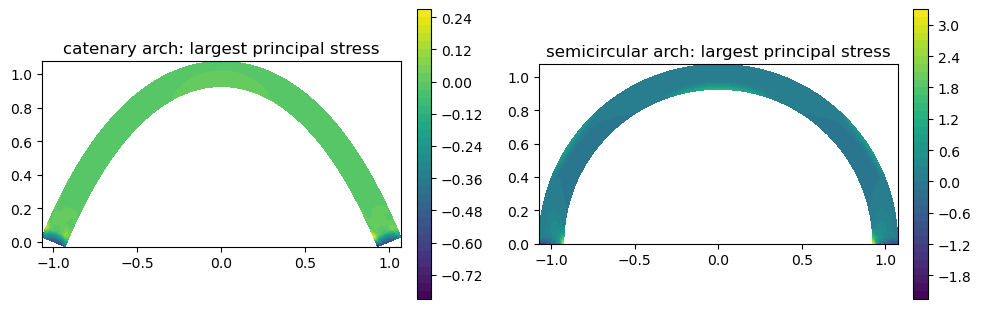

In [4]:
rise, thickness = 1.0, 0.15
a_arch = brentq(lambda a: a*(np.cosh(1/a) - 1) - rise, 0.1, 5.0)     # inverted catenary with rise 1 over the span (-1, 1)

def arch_mesh(centre, normal, n_s=80, n_t=6):
    # rectangle (s, t) in (0, 1)^2 mapped onto the arch: centre line + thickness along the normal
    m = RectangleMesh(Point(0.0, 0.0), Point(1.0, 1.0), n_s, n_t)
    feet = MeshFunction('size_t', m, m.topology().dim() - 1, 0)
    AutoSubDomain(lambda x, on_boundary: on_boundary and (near(x[0], 0.0, tol) or near(x[0], 1.0, tol))).mark(feet, 1)
    s, t = m.coordinates().T.copy()
    cx, cy = centre(s)
    nx, ny = normal(s)
    m.coordinates()[:, 0] = cx + (t - 0.5)*thickness*nx
    m.coordinates()[:, 1] = cy + (t - 0.5)*thickness*ny
    return m, feet

def catenary_centre(s):
    x = -1 + 2*s
    return x, rise - a_arch*(np.cosh(x/a_arch) - 1)

def catenary_normal(s):
    x = -1 + 2*s
    dy = -np.sinh(x/a_arch)
    return -dy/np.sqrt(1 + dy**2), 1/np.sqrt(1 + dy**2)

def circle_centre(s):
    theta = np.pi*(1 - s)
    return np.cos(theta), np.sin(theta)

def circle_normal(s):
    theta = np.pi*(1 - s)
    return np.cos(theta), np.sin(theta)

rho_g = 1.0
pyplot.figure(figsize=(10, 3.2), dpi=100)
for i, (name, centre, normal) in enumerate((('catenary arch', catenary_centre, catenary_normal),
                                            ('semicircular arch', circle_centre, circle_normal))):
    mesh_a, feet = arch_mesh(centre, normal)
    V_a = VectorFunctionSpace(mesh_a, 'Lagrange', 2)
    W_a = FunctionSpace(mesh_a, 'Lagrange', 1)
    u_a = solve_elasticity(V_a, [DirichletBC(V_a, Constant((0.0, 0.0)), feet, 1)], f=Constant((0.0, -rho_g)))
    s_1 = project(rankine(u_a), W_a).vector().max()
    s_3 = -project(sigma_3(u_a), W_a).vector().min()
    print("%-18s  largest tensile stress %.3f   largest compressive stress %.3f   ratio %.2f" % (name, s_1, s_3, s_1/s_3))
    pyplot.subplot(1, 2, i + 1)
    c = plot(rankine(u_a), title=name + ': largest principal stress')
    pyplot.colorbar(c, fraction=0.046, pad=0.04)
pyplot.tight_layout()
pyplot.savefig("catenary-1.png")

## Shape optimization as a gradient flow

The *thermodynamic extremal principle* (Flachberger & Einkemmer, `main.tex` in this folder, Section 2.2) states that a
dissipative system with free energy $\mathcal{F}$ evolves with the rates $v$ that minimize the Rayleighian

$$\mathcal{R}(v) = \dot{\mathcal{F}}(v) + \tfrac12 \, \mathcal{P}(v) ,$$

where the free energy rate $\dot{\mathcal{F}}$ is linear in $v$ and the dissipation $\mathcal{P}$ is a positive quadratic form, for
instance $\int |v|^2 / L \; dx$ with an Onsager coefficient $L$. The minimizer satisfies Onsager's law, and testing its
stationarity condition with $v$ itself gives $\dot{\mathcal{F}} = -\mathcal{P}(v) \leq 0$: the evolution is a gradient flow of
$\mathcal{F}$ (their Section 5.2).

Shape optimization borrows this structure. The state is the domain $\Omega$, the rate is the velocity $v$ of its
boundary, and the free energy is the objective $J(\Omega)$ that we want to make small. Its rate is the **shape
derivative** $J'(\Omega)[v]$, the derivative at $t = 0$ of $J(\Omega_t)$ for the domain $\Omega_t$ obtained by moving every point
$x$ to $x + t \, v(x)$. With the $H^1$ dissipation $\mathcal{P}(v) = \int_\Omega \alpha \, |\nabla v|^2 + |v|^2 \; dx$, which also charges for
moving unevenly and so keeps the mesh smooth, the minimizer of $\mathcal{R}(v) = J'(\Omega)[v] + \tfrac12 \mathcal{P}(v)$ solves

$$\int_\Omega \alpha \, \nabla v : \nabla \varphi + v \cdot \varphi \; dx = -J'(\Omega)[\varphi] \qquad \text{for all } \varphi ,$$

and $J$ decreases at the rate $J'(\Omega)[v] = -\mathcal{P}(v)$. Every step of the algorithm solves this linear problem and
moves the mesh by a small multiple of $v$. A constant volume is imposed by adding $\ell \int_{\partial\Omega} v \cdot n \; ds$, the
rate of change of the area times a multiplier $\ell$, to the Rayleighian, with $\ell$ chosen such that this rate vanishes.
What remains is to compute the driving force $J'(\Omega)[v]$.

### The shape derivative: the Lagrangian method

Let the objective be $J(\Omega) = \int_\Omega j(\sigma(u)) \, dx$, where $u$ is the solution of the elasticity problem on $\Omega$
(body force $f$, traction $T$ on $\Gamma_N$, clamped on $\Gamma_D$), and let $\Gamma$ be the traction-free part of the
boundary, the only part that moves. $J$ depends on the domain twice: through the domain of integration, and through
$u$, which changes everywhere in the body when the boundary moves. The Lagrangian method (Céa 1986) takes care of the
second dependence without ever computing it. Add the weak form of the equilibrium equation, tested with a multiplier
field $z$, to the objective:

$$\mathcal{L}(\Omega, u, z) = \int_\Omega j(\sigma(u)) + \sigma(u) : \varepsilon(z) - f \cdot z \; dx - \int_{\Gamma_N} T \cdot z \; ds .$$

For the solution $u$ the added terms vanish for every admissible $z$ (zero on $\Gamma_D$), so $\mathcal{L} = J$. Now let the
boundary move with $v$ and differentiate $\mathcal{L}$ with the transport theorem
$\frac{d}{dt} \int_{\Omega(t)} g \; dx = \int_\Omega \partial_t g \; dx + \int_{\partial\Omega} g \, v \cdot n \; ds$ (Walker, *The Shapes of Things*,
Lemma 5.7, with $\mathbf{V} = v$, $\boldsymbol{\nu} = n$ and $g' = \partial_t g$): the moving boundary gives a boundary term, and the
integrand changes at fixed points through $u' = \partial_t u$ and $z' = \partial_t z$. With $\sigma(u') : \varepsilon(z) = \sigma(z) : \varepsilon(u')$,
by the symmetry of the elasticity tensor,

$$\begin{aligned}
\frac{d\mathcal{L}}{dt} = {} & \int_\Gamma \big( j + \sigma(u) : \varepsilon(z) - f \cdot z \big) \, v \cdot n \; ds
  + \Big[ \int_\Omega \frac{\partial j}{\partial \sigma} : \sigma(u') + \sigma(z) : \varepsilon(u') \; dx \Big] \\
  & + \Big[ \int_\Omega \sigma(u) : \varepsilon(z') - f \cdot z' \; dx - \int_{\Gamma_N} T \cdot z' \; ds \Big] .
\end{aligned}$$

Both brackets vanish. The second is the equilibrium equation tested with $z'$; it is zero because $u$ is in
equilibrium. The first is zero for every $u'$ if the multiplier $z$ solves the **adjoint problem**

$$\int_\Omega \sigma(z) : \varepsilon(\varphi) \; dx = -\int_\Omega \frac{\partial j}{\partial \sigma} : \sigma(\varphi) \; dx \qquad \text{for all admissible } \varphi$$

($u'$ is admissible: $u = 0$ on the clamped boundary, which does not move). This is the elasticity problem with the
same stiffness and the load $-\partial J / \partial u$, the directional derivative of lecture 2: one more linear solve with the
same matrix, whose right-hand side FEniCS generates with `derivative`. What remains is the boundary term, the shape
derivative

$$J'(\Omega)[v] = \int_\Gamma \big( j + \sigma(u) : \varepsilon(z) - f \cdot z \big) \, v \cdot n \; ds .$$

In short: the adjoint problem fixes the multiplier $z$, the other terms vanish because equilibrium holds, and the shape
derivative is the boundary term that is left.

### The strain energy, other objectives, and the flow

For $j = \psi$ the load of the adjoint problem is $-\int_\Omega \sigma(u) : \varepsilon(\varphi) \, dx$, so $z = -u$: the problem is
*self-adjoint*, and the shape derivative needs no extra solve. With $\sigma(u) : \varepsilon(u) = 2 \psi$,

$$U'(\Omega)[v] = -\int_\Gamma \big( \psi - f \cdot u \big) \, v \cdot n \; ds , \qquad C'(\Omega)[v] = 2 \, U'(\Omega)[v] ,$$

since the compliance $C = \int_\Omega f \cdot u \, dx + \int_{\Gamma_N} T \cdot u \, ds$ equals $2U$ (lecture 2); this is the classic
objective of structural optimization (Allaire, Jouve & Toader 2004). For an equivalent stress of lecture 3 the adjoint
state is a genuine extra solve, and the objective needs some care: for a strip of width $h$ under the normal force $N$,
$\int \sigma_{vM} \, dx = N$ per unit length whatever $h$, so the integral of the von Mises stress cannot tell a thick bar from
a thin one. One uses $\int_\Omega \sigma_{vM}^p \, dx$ with $p \geq 2$, or its $p$-th root with a large $p$ as a smooth stand-in for
the largest stress (Allaire & Jouve 2008). Example 3 checks the shape derivative for $j = \psi$ and for $j = \sigma_{vM}^2$
against finite differences, and example 5 runs the flow for $j = \sigma_{vM}^p$.

Inserted into the gradient flow, the shape derivative determines the velocity: with $g = j + \sigma(u) : \varepsilon(z) - f \cdot z$,

$$\int_\Omega \alpha \, \nabla v : \nabla \varphi + v \cdot \varphi \; dx = -\int_\Gamma \big( g + \ell \big) \, \varphi \cdot n \; ds \qquad \text{for all } \varphi ,$$

with $\ell$ such that $\int_\Gamma v \cdot n \; ds = 0$. For the strain energy $-(g + \ell) = \psi - f \cdot u - \ell$: the boundary moves
outward where the energy density is above $\ell$ and inward where it is below, so material moves to where it carries
load.

### 3. Checking the shape derivative

The cantilever of lecture 3 with the end load $T = (0, -0.5)$ and no body force. The top edge is moved by
$\varepsilon \sin^2(\pi x / 5)$, a bump that vanishes at the clamped and at the loaded end, with the interior nodes following
proportionally to $y$. For two objectives, the strain energy ($j = \psi$) and the integral of the squared von Mises
stress ($j = \sigma_{vM}^2$), the adjoint problem is solved with the load generated by `derivative`, the shape derivative
is evaluated as the boundary integral over the top edge, and both are compared with central finite differences of
$J$ computed on the moved meshes. For $j = \psi$ the adjoint state must be $z = -u$. Clapeyron's $C = 2U$ of lecture 2
is checked as well.

In [5]:
length, height = 5.0, 1.0
mesh = RectangleMesh(Point(0.0, 0.0), Point(length, height), 50, 10)
V = VectorFunctionSpace(mesh, 'Lagrange', 2)
W = FunctionSpace(mesh, 'Lagrange', 1)

def right(x, on_boundary):
    return on_boundary and near(x[0], length, tol)

def top(x, on_boundary):
    return on_boundary and near(x[1], height, tol)

boundaries = MeshFunction('size_t', mesh, mesh.topology().dim() - 1, 0)
AutoSubDomain(right).mark(boundaries, 1)
AutoSubDomain(top).mark(boundaries, 2)
ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

T   = Constant((0.0, -0.5))
bcs = [DirichletBC(V, Constant((0.0, 0.0)), left)]
u0  = solve_elasticity(V, bcs, T=T, ds_T=ds(1))
U0  = assemble(psi(epsilon(u0))*dx)
C0  = assemble(dot(T, u0)*ds(1))
print("strain energy U = %.6f,  compliance C = %.6f,  C/U = %.4f" % (U0, C0, C0/U0))

def von_mises_squared(u):
    # 3/2 s:s with the deviator s of the plane-strain stress: a polynomial in the strain, unlike von_mises(u)**2
    s, s_zz = sigma(u), (K - 2*G/3)*tr(epsilon(u))
    return 1.5*(inner(s, s) + s_zz**2 - (tr(s) + s_zz)**2/3)

def adjoint_state(j, u):
    # int sigma(z) : epsilon(phi) dx = -J_u[phi], the load generated by automatic differentiation
    z, phi = TrialFunction(V), TestFunction(V)
    z_h = Function(V)
    solve(inner(sigma(z), epsilon(phi))*dx == -derivative(j(u)*dx, u, phi), z_h, bcs)
    return z_h

bump = Expression("pow(sin(pi*x[0]/L), 2)", L=length, degree=4)    # v.n on the top edge

X0 = mesh.coordinates().copy()
def objective_on_moved_mesh(j, eps):
    mesh.coordinates()[:] = X0
    shift = interpolate(Expression(("0.0", "eps*pow(sin(pi*x[0]/L), 2)*x[1]/H"), eps=eps, L=length, H=height, degree=4),
                        VectorFunctionSpace(mesh, 'Lagrange', 1))
    ALE.move(mesh, shift)
    J = assemble(j(solve_elasticity(V, bcs, T=T, ds_T=ds(1)))*dx)
    mesh.coordinates()[:] = X0
    return J

eps = 1e-3
for name, j in (("strain energy, j = psi", lambda u: psi(epsilon(u))),
                ("squared von Mises stress, j = sigma_vM^2", von_mises_squared)):
    z = adjoint_state(j, u0)
    shape_derivative = assemble((j(u0) + inner(sigma(u0), epsilon(z)))*bump*ds(2))    # no body force: f.z = 0
    fd = (objective_on_moved_mesh(j, eps) - objective_on_moved_mesh(j, -eps))/(2*eps)
    print(name)
    print("  shape derivative %10.6f   finite differences %10.6f   relative difference %.1e"
          % (shape_derivative, fd, abs(fd - shape_derivative)/abs(shape_derivative)))
    if name.startswith("strain energy"):
        print("  self-adjoint, z = -u:  |z + u| / |u| = %.1e" % ((z.vector() + u0.vector()).norm('l2')/u0.vector().norm('l2')))

Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Calling FFC just-in-time (JIT) compiler, this may take some time.


strain energy, j = psi
  shape derivative  -0.072265   finite differences  -0.072283   relative difference 2.4e-04
  self-adjoint, z = -u:  |z + u| / |u| = 4.1e-10
Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


squared von Mises stress, j = sigma_vM^2
  shape derivative -125.298205   finite differences -125.325512   relative difference 2.2e-04


For both objectives the shape derivative agrees with the finite differences to $2 \cdot 10^{-4}$, the level of the
discretization error, and for $j = \psi$ the adjoint solve returns $z = -u$. The recipe is the same for every $j$: write
down $J$, let `derivative` produce the load of the adjoint problem, solve it with the stiffness matrix of the elasticity
problem, and evaluate the boundary integral.

## Optimizing the cantilever

The cantilever of lecture 3 (length 5, height 1) under its own weight, $f = (0, -0.3)$, clamped at $x = 0$, is optimized
with the flow, first for the strain energy (example 4), then for the von Mises stress (example 5). Two details of the mesh motion matter. On the clamped edge only the horizontal
component of the velocity is prescribed, $v_x = 0$: the nodes of the edge slide vertically, so that the clamped end,
where a cantilever needs material most, can grow, and one node, $(0, \tfrac12)$, is pinned completely to keep the beam in
place. The displacement $u$ remains clamped on the edge, which stays at $x = 0$. And the velocity is scaled in every
step so that the largest node moves by $3\,\%$ of the height. The function `shape_flow` performs one run: in every
step it solves the elasticity problem, computes the velocity (`w` in the code) from the shape derivative (for an objective
other than the strain energy after one more solve for the adjoint state), moves the mesh, and prints the area, the largest displacement, the largest von Mises stress, the compliance and the quality of
the worst cell.

In [6]:
def shape_flow(mesh0, bcs_u, bcs_w, free, f=Constant((0.0, 0.0)), T=None, loaded=None,
               nr_steps=10, alpha=3.0, step=0.03, volume=False, chi=Constant(1.0), j=None, label=""):
    # gradient flow of J = int j dx: boundary data -g (times the cut-off chi) on the free boundary, H1 extension into
    # the domain, a multiplier that keeps the volume to first order if volume=True, and a step that moves the largest
    # node by `step`; j=None is the strain energy (self-adjoint, -g = psi - f.u), otherwise j(u) is the objective density
    mesh = Mesh(mesh0)
    V  = VectorFunctionSpace(mesh, 'Lagrange', 2)
    Vw = VectorFunctionSpace(mesh, 'Lagrange', 1)      # mesh velocity, same degree as the mesh geometry
    W  = FunctionSpace(mesh, 'Lagrange', 1)
    marks = MeshFunction('size_t', mesh, mesh.topology().dim() - 1, 0)
    AutoSubDomain(free).mark(marks, 1)
    AutoSubDomain(left).mark(marks, 2)
    if loaded is not None:
        AutoSubDomain(loaded).mark(marks, 3)
    ds = Measure('ds', domain=mesh, subdomain_data=marks)
    n  = FacetNormal(mesh)
    bcs_u, bcs_w = bcs_u(V), bcs_w(Vw)
    history = []
    print(label)
    for k in range(nr_steps + 1):
        u  = solve_elasticity(V, bcs_u, f=f, T=T, ds_T=ds(3) if T is not None else None)
        vm = project(von_mises(u), W)
        compliance = assemble(dot(f, u)*dx) + (assemble(dot(T, u)*ds(3)) if T is not None else 0.0)
        history.append((assemble(1.0*dx(domain=mesh)), u.vector().norm('linf'), vm.vector().max(), compliance,
                        MeshQuality.radius_ratio_min_max(mesh)[0]))
        line = "  step %2d: area %.3f  max |u| %.4f  max von Mises %6.2f  compliance %.4f  min radius ratio %.2f" % ((k,) + history[-1])
        print(line + ("  objective %.4g" % assemble(j(u)*dx) if j is not None else ""))
        if k == nr_steps:
            break
        w, phi = TrialFunction(Vw), TestFunction(Vw)
        a_w = ( alpha*inner(grad(w), grad(phi)) + inner(w, phi) )*dx            # the H1 dissipation
        if j is None:                                                             # strain energy: z = -u, -g = psi - f.u
            drive = (psi(epsilon(u)) - dot(f, u))*chi
        else:                                                                     # adjoint state: one more solve, same matrix
            z, phi_u = Function(V), TestFunction(V)
            solve(inner(sigma(TrialFunction(V)), epsilon(phi_u))*dx == -derivative(j(u)*dx, u, phi_u), z, bcs_u)
            drive = -(j(u) + inner(sigma(u), epsilon(z)) - dot(f, z))*chi
        w = Function(Vw)
        solve(a_w == drive*dot(phi, n)*ds(1), w, bcs_w)
        if volume:                                                                # multiplier: no volume change to first order
            w_1 = Function(Vw)
            solve(a_w == chi*dot(phi, n)*ds(1), w_1, bcs_w)
            w.vector().axpy(-assemble(dot(w, n)*ds(1))/assemble(dot(w_1, n)*ds(1)), w_1.vector())
        w.vector()[:] *= step/w.vector().norm('linf')
        ALE.move(mesh, w)
    return mesh, u, history

def show_shape(mesh0, mesh, title, filename):
    pyplot.figure(figsize=(8, 2.4), dpi=100)
    plot(mesh0, color='lightgray')
    plot(mesh, title=title)
    pyplot.tight_layout()
    pyplot.savefig(filename)

mesh0 = RectangleMesh(Point(0.0, 0.0), Point(length, height), 50, 10)
rho_g = 0.3
f_weight = Constant((0.0, -rho_g))

clamped   = lambda V:  [DirichletBC(V, Constant((0.0, 0.0)), left)]               # displacement: clamped left edge
w_slide   = lambda Vw: [DirichletBC(Vw.sub(0), Constant(0.0), left),               # velocity: the edge slides vertically,
                        DirichletBC(Vw, Constant((0.0, 0.0)), "near(x[0], 0.0) && near(x[1], 0.5)", method="pointwise")]  # one node pinned
free_cant = lambda x, on_boundary: on_boundary and not near(x[0], 0.0, tol)      # everything but the clamped edge may move

### 4. The shape derivative flow, volume preserved

Twenty steps of the flow for the strain energy with the boundary data $\psi - f \cdot u - \ell$ on the free boundary, the
multiplier $\ell$ chosen in every step such that the volume does not change to first order (`volume=True`). For
comparison the same flow without the volume constraint ($\ell = 0$): with the own weight as the load, removing material
that only adds weight is also a way to reduce the compliance.

shape derivative, volume preserved
Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


  step  0: area 5.000  max |u| 0.2651  max von Mises  22.73  compliance 0.1633  min radius ratio 0.83
Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


...

  step  1: area 5.003  max |u| 0.2382  max von Mises  21.62  compliance 0.1441  min radius ratio 0.81
  step  2: area 5.007  max |u| 0.2151  max von Mises  20.61  compliance 0.1280  min radius ratio 0.80
  step  3: area 5.010  max |u| 0.1952  max von Mises  19.69  compliance 0.1143  min radius ratio 0.79
  step  4: area 5.013  max |u| 0.1779  max von Mises  18.85  compliance 0.1025  min radius ratio 0.77
  step  5: area 5.016  max |u| 0.1626  max von Mises  18.07  compliance 0.0924  min radius ratio 0.76
  step  6: area 5.019  max |u| 0.1491  max von Mises  17.35  compliance 0.0835  min radius ratio 0.75
  step  7: area 5.022  max |u| 0.1371  max von Mises  16.69  compliance 0.0757  min radius ratio 0.74
  step  8: area 5.024  max |u| 0.1264  max von Mises  16.06  compliance 0.0688  min radius ratio 0.73
  step  9: area 5.027  max |u| 0.1167  max von Mises  15.48  compliance 0.0628  min radius ratio 0.72
  step 10: area 5.030  max |u| 0.1080  max von Mises  14.93  compliance 0.0574  mi

  step 11: area 5.032  max |u| 0.1001  max von Mises  14.42  compliance 0.0525  min radius ratio 0.70
  step 12: area 5.035  max |u| 0.0930  max von Mises  13.93  compliance 0.0482  min radius ratio 0.69
  step 13: area 5.037  max |u| 0.0865  max von Mises  13.48  compliance 0.0444  min radius ratio 0.68
  step 14: area 5.040  max |u| 0.0805  max von Mises  13.04  compliance 0.0409  min radius ratio 0.67
  step 15: area 5.042  max |u| 0.0750  max von Mises  12.63  compliance 0.0377  min radius ratio 0.66
  step 16: area 5.045  max |u| 0.0700  max von Mises  12.24  compliance 0.0349  min radius ratio 0.65
  step 17: area 5.047  max |u| 0.0654  max von Mises  11.87  compliance 0.0323  min radius ratio 0.64
  step 18: area 5.049  max |u| 0.0612  max von Mises  11.51  compliance 0.0299  min radius ratio 0.64
  step 19: area 5.052  max |u| 0.0573  max von Mises  11.17  compliance 0.0278  min radius ratio 0.63
  step 20: area 5.054  max |u| 0.0537  max von Mises  10.85  compliance 0.0259  mi

  step  9: area 4.794  max |u| 0.1387  max von Mises  16.27  compliance 0.0729  min radius ratio 0.75
  step 10: area 4.770  max |u| 0.1304  max von Mises  15.76  compliance 0.0674  min radius ratio 0.75
  step 11: area 4.746  max |u| 0.1227  max von Mises  15.27  compliance 0.0624  min radius ratio 0.74
  step 12: area 4.722  max |u| 0.1157  max von Mises  14.81  compliance 0.0579  min radius ratio 0.73
  step 13: area 4.697  max |u| 0.1092  max von Mises  14.37  compliance 0.0538  min radius ratio 0.73
  step 14: area 4.673  max |u| 0.1031  max von Mises  13.95  compliance 0.0500  min radius ratio 0.72
  step 15: area 4.648  max |u| 0.0975  max von Mises  13.56  compliance 0.0466  min radius ratio 0.72
  step 16: area 4.623  max |u| 0.0923  max von Mises  13.18  compliance 0.0434  min radius ratio 0.71
  step 17: area 4.597  max |u| 0.0874  max von Mises  12.81  compliance 0.0405  min radius ratio 0.71
  step 18: area 4.572  max |u| 0.0828  max von Mises  12.46  compliance 0.0379  mi

Calling FFC just-in-time (JIT) compiler, this may take some time.


                                       area   compliance  max von Mises  radius ratio
initial beam                          5.000       0.1633          22.73          0.83
volume preserved, 10 steps            5.030       0.0574          14.93          0.71
volume preserved, 20 steps            5.054       0.0259          10.85          0.62
no volume constraint, 20 steps        4.521       0.0331          11.81          0.69


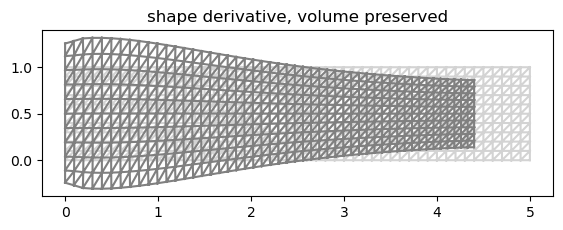

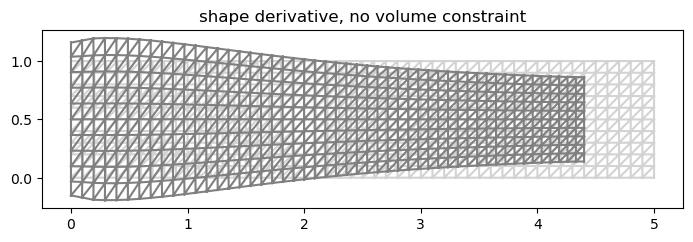

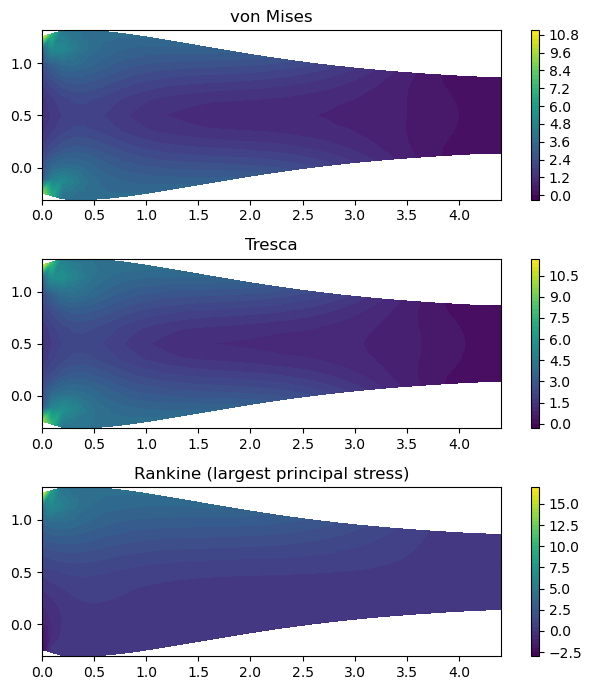

In [7]:
mesh_en, u_en, hist_en = shape_flow(mesh0, clamped, w_slide, free_cant, f=f_weight, nr_steps=20, volume=True,
                                    label="shape derivative, volume preserved")
mesh_en0, u_en0, hist_en0 = shape_flow(mesh0, clamped, w_slide, free_cant, f=f_weight, nr_steps=20, volume=False,
                                       label="shape derivative, no volume constraint")
show_shape(mesh0, mesh_en,  'shape derivative, volume preserved', "shape-0.png")
show_shape(mesh0, mesh_en0, 'shape derivative, no volume constraint', "shape-1.png")
show_stresses(u_en, "shape-2.png")

print("%-34s %8s %12s %14s %13s" % ("", "area", "compliance", "max von Mises", "radius ratio"))
for name, hist in (("initial beam", hist_en[:1]), ("volume preserved, 10 steps", hist_en[:11]),
                   ("volume preserved, 20 steps", hist_en), ("no volume constraint, 20 steps", hist_en0)):
    area, umax, vm, compliance, rr = hist[-1]
    print("%-34s %8.3f %12.4f %14.2f %13.2f" % (name, area, compliance, vm, rr))

At constant volume the compliance drops to a sixth of its initial value in twenty steps ($0.163 \to 0.026$), and the
largest von Mises stress to less than half ($22.7 \to 10.9$). The beam becomes a tapered cantilever: the clamped end,
free to slide, grows from height $1$ to about $1.5$, the beam thins towards the tip, and the tip itself retracts from
$x = 5$ to about $4.4$, because the material there carries little more than its own weight. The flow comes to rest when
$\psi - f \cdot u$ takes the same value $\ell$ along the whole free boundary; after twenty steps it is not there yet, the
compliance still falls. The stress plots show the equivalent stresses of lecture 3 on the result: the largest values
sit in the clamped corners, where the stress is singular (lecture 3) and no smooth change of the shape helps;
elsewhere they are much lower and decrease towards the tip. The area changes by $1\,\%$, because the multiplier keeps
the volume only to first order. Without the volume constraint the flow arrives at a similar shape with $10\,\%$ less
material and a compliance of $0.033$: removing material that mainly adds weight also reduces the compliance.

Two remarks for anyone who wants to go on from here. First, the mesh: every step moves the nodes of one and the same
mesh, so its quality (the radius ratio of the worst cell) decays, and after a few dozen steps the mesh has to be
regenerated; level-set methods avoid the problem by moving the boundary through a fixed mesh. Second, the objective:
the compliance measures stiffness, not strength; example 5 takes the failure criterion of lecture 3 as the objective
instead.

### 5. The von Mises stress as the objective

Now the failure criterion of lecture 3 as the objective, $J = \int_\Omega \sigma_{vM}^p \, dx$: for even $p$ a polynomial in the
strain, scaled by $\sigma_{\mathrm{ref}} = 10$ only to keep the numbers readable. In every step `shape_flow` solves the adjoint
problem, with the load generated by `derivative` and the stiffness of the elasticity problem, and moves the boundary
with the data $-(g + \ell)$, $g = j + \sigma(u) : \varepsilon(z) - f \cdot z$ (option `j`); everything else is as in example 4. Two
exponents: $p = 4$, and $p = 8$, which comes closer to the largest stress. The table compares the results with
example 4 by the compliance, the largest von Mises stress, the largest von Mises stress away from the singular
clamped corners ($x > 1/4$), the $4$-mean $\big(\int_\Omega \sigma_{vM}^4 \, dx / |\Omega|\big)^{1/4}$, and the radius ratio of the worst cell.

objective: integral of sigma_vM^4, volume preserved
Calling FFC just-in-time (JIT) compiler, this may take some time.


  step  0: area 5.000  max |u| 0.2651  max von Mises  22.73  compliance 0.1633  min radius ratio 0.83  objective 1.75
Calling FFC just-in-time (JIT) compiler, this may take some time.


Calling FFC just-in-time (JIT) compiler, this may take some time.


  step  1: area 5.005  max |u| 0.2345  max von Mises  21.30  compliance 0.1411  min radius ratio 0.81  objective 1.203
  step  2: area 5.009  max |u| 0.2091  max von Mises  20.06  compliance 0.1230  min radius ratio 0.79  objective 0.8544
  step  3: area 5.013  max |u| 0.1881  max von Mises  18.99  compliance 0.1083  min radius ratio 0.77  objective 0.6264
  step  4: area 5.017  max |u| 0.1703  max von Mises  18.04  compliance 0.0962  min radius ratio 0.76  objective 0.4707
  step  5: area 5.021  max |u| 0.1550  max von Mises  17.20  compliance 0.0859  min radius ratio 0.75  objective 0.3606
  step  6: area 5.024  max |u| 0.1417  max von Mises  16.44  compliance 0.0771  min radius ratio 0.73  objective 0.2807
  step  7: area 5.027  max |u| 0.1300  max von Mises  15.75  compliance 0.0696  min radius ratio 0.72  objective 0.2215


  step  8: area 5.030  max |u| 0.1197  max von Mises  15.12  compliance 0.0630  min radius ratio 0.71  objective 0.1769
  step  9: area 5.033  max |u| 0.1105  max von Mises  14.54  compliance 0.0573  min radius ratio 0.69  objective 0.1426
  step 10: area 5.036  max |u| 0.1022  max von Mises  14.00  compliance 0.0522  min radius ratio 0.68  objective 0.116
  step 11: area 5.039  max |u| 0.0947  max von Mises  13.49  compliance 0.0477  min radius ratio 0.66  objective 0.09519
  step 12: area 5.042  max |u| 0.0880  max von Mises  13.03  compliance 0.0438  min radius ratio 0.65  objective 0.07864
  step 13: area 5.044  max |u| 0.0819  max von Mises  12.59  compliance 0.0402  min radius ratio 0.64  objective 0.06541


...

  step  1: area 5.003  max |u| 0.2448  max von Mises  21.92  compliance 0.1485  min radius ratio 0.81  objective 5.337
  step  2: area 5.005  max |u| 0.2273  max von Mises  21.32  compliance 0.1361  min radius ratio 0.77  objective 3.526
  step  3: area 5.007  max |u| 0.2123  max von Mises  20.85  compliance 0.1257  min radius ratio 0.73  objective 2.527
  step  4: area 5.009  max |u| 0.1985  max von Mises  20.39  compliance 0.1164  min radius ratio 0.68  objective 1.848
  step  5: area 5.010  max |u| 0.1848  max von Mises  19.85  compliance 0.1072  min radius ratio 0.64  objective 1.324
  step  6: area 5.012  max |u| 0.1713  max von Mises  19.28  compliance 0.0983  min radius ratio 0.59  objective 0.9506


  step  7: area 5.014  max |u| 0.1593  max von Mises  18.82  compliance 0.0907  min radius ratio 0.55  objective 0.7208
  step  8: area 5.015  max |u| 0.1488  max von Mises  18.38  compliance 0.0840  min radius ratio 0.52  objective 0.5598
  step  9: area 5.016  max |u| 0.1392  max von Mises  17.97  compliance 0.0781  min radius ratio 0.49  objective 0.4429
  step 10: area 5.017  max |u| 0.1308  max von Mises  17.63  compliance 0.0731  min radius ratio 0.46  objective 0.3674
  step 11: area 5.018  max |u| 0.1232  max von Mises  17.31  compliance 0.0685  min radius ratio 0.44  objective 0.3067
  step 12: area 5.018  max |u| 0.1163  max von Mises  16.99  compliance 0.0645  min radius ratio 0.43  objective 0.2598


  step 13: area 5.019  max |u| 0.1102  max von Mises  16.77  compliance 0.0610  min radius ratio 0.42  objective 0.2303
  step 14: area 5.019  max |u| 0.1044  max von Mises  16.49  compliance 0.0577  min radius ratio 0.41  objective 0.1991
  step 15: area 5.020  max |u| 0.0992  max von Mises  16.25  compliance 0.0547  min radius ratio 0.40  objective 0.1772
  step 16: area 5.020  max |u| 0.0947  max von Mises  16.10  compliance 0.0523  min radius ratio 0.39  objective 0.1638
  step 17: area 5.020  max |u| 0.0901  max von Mises  15.81  compliance 0.0496  min radius ratio 0.40  objective 0.1415
  step 18: area 5.020  max |u| 0.0862  max von Mises  15.65  compliance 0.0475  min radius ratio 0.39  objective 0.1323
  step 19: area 5.020  max |u| 0.0827  max von Mises  15.52  compliance 0.0457  min radius ratio 0.38  objective 0.1232
  step 20: area 5.021  max |u| 0.0787  max von Mises  15.19  compliance 0.0434  min radius ratio 0.39  objective 0.1046


after 20 steps                    area  compliance   max vM  max vM, x>1/4  4-mean   ratio
Calling FFC just-in-time (JIT) compiler, this may take some time.


initial beam                     5.000      0.1633    22.73          17.17   7.692    0.83
strain energy (example 4)        5.054      0.0259    10.85           4.59   2.715    0.62
von Mises, p = 4                 5.061      0.0234    10.13           4.16   2.537    0.55
von Mises, p = 8                 5.021      0.0434    15.19           9.87   3.946    0.39


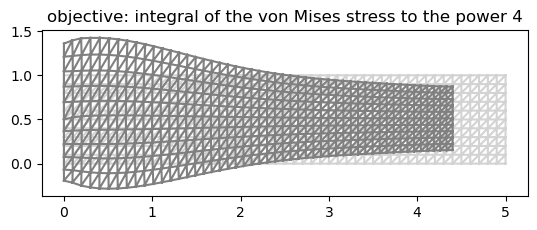

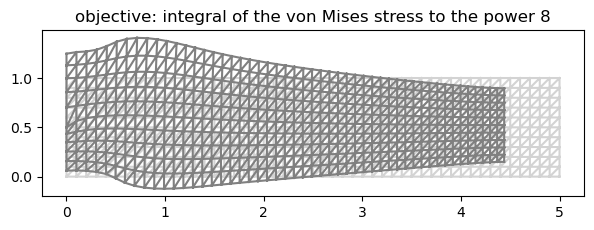

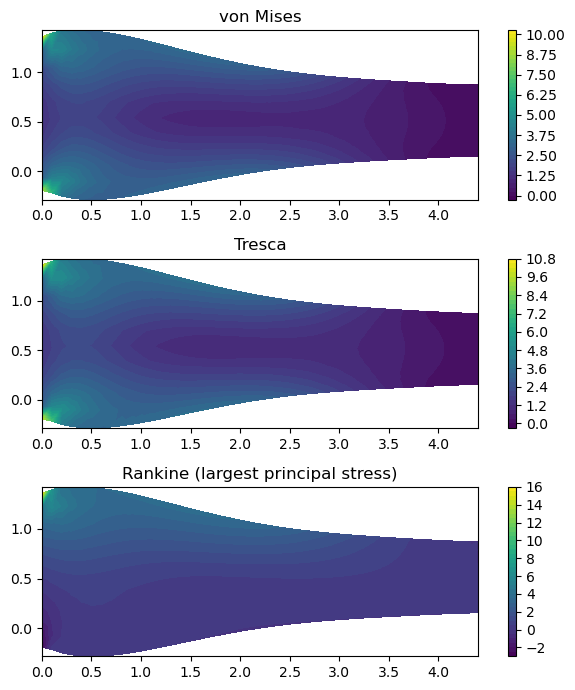

In [8]:
def von_mises_power(p):
    # j = (sigma_vM / 10)^p for even p: a polynomial in the strain, so derivative() needs no square roots
    return lambda u: (von_mises_squared(u)/100)**(p//2)

mesh_p4, u_p4, hist_p4 = shape_flow(mesh0, clamped, w_slide, free_cant, f=f_weight, nr_steps=20, volume=True,
                                    j=von_mises_power(4), label="objective: integral of sigma_vM^4, volume preserved")
mesh_p8, u_p8, hist_p8 = shape_flow(mesh0, clamped, w_slide, free_cant, f=f_weight, nr_steps=20, volume=True,
                                    j=von_mises_power(8), label="objective: integral of sigma_vM^8, volume preserved")
show_shape(mesh0, mesh_p4, 'objective: integral of the von Mises stress to the power 4', "shape-3.png")
show_shape(mesh0, mesh_p8, 'objective: integral of the von Mises stress to the power 8', "shape-4.png")
show_stresses(u_p4, "shape-5.png")

def stress_summary(u):
    mesh = u.function_space().mesh()
    W = FunctionSpace(mesh, 'Lagrange', 1)
    vm = project(von_mises(u), W)
    away = W.tabulate_dof_coordinates()[:, 0] > 0.25                       # without the singular clamped corners
    area = assemble(1.0*dx(domain=mesh))
    return (area, assemble(dot(f_weight, u)*dx), vm.vector().max(), vm.vector().get_local()[away].max(),
            (assemble(von_mises_squared(u)**2*dx)/area)**0.25, MeshQuality.radius_ratio_min_max(mesh)[0])

V_0 = VectorFunctionSpace(mesh0, 'Lagrange', 2)
u_initial = solve_elasticity(V_0, clamped(V_0), f=f_weight)
print("%-30s %7s %11s %8s %14s %7s %7s" % ("after 20 steps", "area", "compliance", "max vM", "max vM, x>1/4", "4-mean", "ratio"))
for name, u in (("initial beam", u_initial), ("strain energy (example 4)", u_en),
                ("von Mises, p = 4", u_p4), ("von Mises, p = 8", u_p8)):
    print("%-30s %7.3f %11.4f %8.2f %14.2f %7.3f %7.2f" % ((name,) + stress_summary(u)))

With $p = 4$ the flow arrives at a shape close to that of example 4, with somewhat more material around the clamped
end, and after twenty steps it is ahead in every stress measure: away from the corners the largest von Mises stress
drops from $17.2$ to $4.2$ ($4.6$ for the compliance flow), the 4-mean from $7.7$ to $2.5$ ($2.7$). It is even slightly
ahead in the compliance, $0.023$ against $0.026$, which only says that neither flow has arrived yet: both still move
after twenty steps, and only converged runs, on a regenerated mesh, would show how the stiffest and the strongest beam
differ. The stress plots show where the remaining peaks sit: in the clamped corners.

With $p = 8$ every measure is worse. The objective now comes close to the largest stress, and the largest stress sits
in the singular clamped corners (lecture 3), where it grows without bound as the mesh is refined. The flow spends its
steps reshaping the boundary next to the corners: a neck forms beside the clamped edge, the beam becomes thickest at
$x \approx 0.8$ instead of at the support, and the mesh degrades quickly (radius ratio $0.39$). A stress objective
therefore needs a remedy for singular points, for instance a weight that excludes a neighbourhood of the corners
from $J$ (Allaire & Jouve 2008), or rounded corners in the model.

## Exercises

### Exercise 1: The catenary

1. Derive the Euler–Lagrange equation of $\mathcal{L}[y, \lambda] = \int_0^1 (\rho g \, y - \lambda)\sqrt{1 + (y')^2} \, dx$
   and show that $\frac{\rho g \, y - \lambda}{\sqrt{1 + (y')^2}} = H$ is a first integral. Verify that
   $y = \lambda / \rho g + a \cosh((x - x_0)/a)$ with $a = H / \rho g$ solves it.
2. Interpret $H$ and $\lambda$: consider the equilibrium of a piece of the rope between its lowest point and a
   point $x$ (horizontal force $H$, vertical force equal to the weight $\rho g \, s(x)$ of the piece, $s$ the arc length)
   and show that the rope force is $\rho g \, (y - \lambda / \rho g)$, hence $\lambda = \rho g \, (y_{\min} - a)$.
3. Check with the solution of example 1: compare $y_{\min} - \lambda_h$ with $a$, and the rope force at the supports,
   $-\lambda_h$, with $a \cosh(1/2a)$. What happens to $a$ and to the rope force when $\ell \to 1$?

### Exercise 2: The shape derivative with a body force

1. Lecture 2 showed that the solution $u$ of the elasticity problem minimizes $\Pi(v, \Omega) = \int_\Omega \psi(\varepsilon(v)) - f \cdot v \; dx - \int_{\Gamma_N} T \cdot v \; ds$
   and that the minimum value is $\Pi(u, \Omega) = -U(\Omega)$. Use this to derive the shape derivative
   $U'(\Omega)[v] = -\int_\Gamma (\psi - f \cdot u) \, v \cdot n \; ds$ for a traction-free moving boundary $\Gamma$.
   (Hint: the derivative of a minimum value with respect to a parameter equals the partial derivative of the
   function at the minimizer, and moving the boundary by $v$ changes $\int_\Omega g \; dx$ by $\int_{\partial\Omega} g \, v \cdot n \; ds$.)
2. Repeat the finite-difference check of example 3 for the cantilever under its own weight and show that the
   term $-f \cdot u$ is needed. What is the sign of this term where the beam sags, and what does it mean for the flow?

### Exercise 3: The end-loaded cantilever

Optimize the cantilever with the end load $T = (0, -0.5)$ of example 3 (no body force) with the shape-derivative flow
at constant volume. The loaded edge must keep its shape (the load is a traction per unit length of it), so the mesh
velocity vanishes there, and the driving force is tapered to zero over the last part of the beam with the cut-off
`chi` below, so that the moving and the fixed part of the boundary are not torn apart.

1. Run ten steps and look at the shape. Beam theory says that a cantilever of constant bending stress under an end
   load has a depth proportional to $\sqrt{L - x}$; does the result go in this direction?
2. Watch the radius ratio. Why does the mesh degrade faster than in example 4, and what would one do about it in
   practice?